## Data Imputation Approaches

- creates and compares results of three imputation methods over a fake gap
- best imputation method is used to fill the real gap in the data
- exports 'all_data_imputed_with_gaps.csv'


### Set up 
Run these cells when restarting

In [192]:
### IMPORTS
import pandas as pd
import numpy as np
from itertools import cycle
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import pickle

In [193]:
### LOAD ROUTE STOP SEQUENCES
with open("Datasets/route_stop_sequences.pkl", "rb") as f:
    route_stop_sequences = pickle.load(f)

### LOAD BUS DATA
#bus_df = pd.read_csv("missing_data_imputation/bus_data_after_missing.csv")
bus_df = pd.read_csv("data/all_data_final.csv")
bus_df["rt"] = bus_df["rt"].astype(str).str.strip()

### LOAD STOPS
stops_df = pd.read_csv("Datasets/stops.txt")[["stop_id", "stop_name", "stop_lat", "stop_lon"]]

### LOAD TRIPS AND STOP TIMES
trips_df = pd.read_csv("Datasets/trips.txt")[["route_id", "trip_id"]]
trips_df["route_id"] = trips_df["route_id"].astype(str).str.strip()
relevant_routes = set(bus_df["rt"])
relevant_trips = set(trips_df[trips_df["route_id"].isin(relevant_routes)]["trip_id"])
stop_times_df = pd.read_csv("Datasets/stop_times.txt")[["trip_id", "stop_id"]]
stop_times_df = stop_times_df[stop_times_df["trip_id"].isin(relevant_trips)]


In [194]:
# if errors, try running this

stop_times_df = pd.read_csv("Datasets/stop_times.txt")[
    ["trip_id", "stop_id", "stop_sequence", "departure_time"]]
stop_times_df = stop_times_df[stop_times_df["trip_id"].isin(relevant_trips)]

In [195]:
### GRAPHING SET UP

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
    'axes.grid':         True,
    'grid.color':        '#2a2a3a',
    'grid.linewidth':    0.5,
    'axes.facecolor':    '#0f0f1a',
    'figure.facecolor':  '#0f0f1a',
    'text.color':        '#e0e0f0',
    'axes.labelcolor':   '#e0e0f0',
    'xtick.color':       '#888899',
    'ytick.color':       '#888899',
    'axes.titlecolor':   '#ffffff',
    'axes.titlesize':    13,
    'axes.labelsize':    10,
})

BG      = '#0f0f1a'
PANEL   = '#16162a'
GREEN   = '#00e5a0'
YELLOW  = '#f0c040'
ORANGE  = '#ff7c40'
RED     = '#ff3860'
BLUE    = '#4488ff'
GREY    = '#555577'
WHITE   = '#e0e0f0'

def otp_color(v):
    if v >= 85:  return GREEN
    if v >= 75:  return YELLOW
    if v >= 65:  return ORANGE
    return RED
print("✓ Setup complete")

✓ Setup complete


### Functions

In [196]:
def match_bus_to_stops(bus_df, stops_df, trips_df, stop_times_df, radius=0.0002):
    """
    matches each bus observation to its nearest valid stop for that route
    using a cKDTree spatial lookup.
    returns bus_with_stops_df with an added stop_id column.
    """
    trip_to_route = trips_df.set_index("trip_id")["route_id"].to_dict()
    stop_times_df["route_id"] = stop_times_df["trip_id"].map(trip_to_route)
    route_to_stops = (
        stop_times_df.groupby("route_id")["stop_id"]
        .apply(set)
        .to_dict()
    )

    stop_coords = stops_df[["stop_lat", "stop_lon"]].values
    stop_tree = cKDTree(stop_coords)

    def assign_stop_id(bus_lat, bus_lon, route_id):
        indices = stop_tree.query_ball_point([bus_lat, bus_lon], r=radius)
        if not indices:
            return None
        valid_stops_for_route = route_to_stops.get(route_id, set())
        valid_indices = [
            i for i in indices
            if stops_df.iloc[i]["stop_id"] in valid_stops_for_route
        ]
        if not valid_indices:
            return None
        if len(valid_indices) > 1:
            candidate_coords = stop_coords[valid_indices]
            distances = np.linalg.norm(candidate_coords - np.array([bus_lat, bus_lon]), axis=1)
            nearest_idx = valid_indices[np.argmin(distances)]
        else:
            nearest_idx = valid_indices[0]
        return stops_df.iloc[nearest_idx]["stop_id"]

    bus_with_stops_df = bus_df.copy()
    bus_with_stops_df["stop_id"] = bus_with_stops_df.apply(
        lambda row: assign_stop_id(row["lat"], row["lon"], row["rt"]), axis=1
    )

    matched = bus_with_stops_df["stop_id"].notna().sum()
    total = len(bus_with_stops_df)
    print(f"Matched {matched}/{total} rows ({matched/total:.1%}) to a stop")

    return bus_with_stops_df

In [197]:
def get_nearest_stop(lat, lon, seq_df, stops_df):
    """
    finds the nearest stop in a route sequence to a given lat/lon.
    returns the stop_id
    """
    seq_stops = stops_df[stops_df["stop_id"].isin(seq_df["stop_id"])]
    if seq_stops.empty:
        return None
    coords = seq_stops[["stop_lat", "stop_lon"]].values
    dists  = np.linalg.norm(coords - np.array([lat, lon]), axis=1)
    return seq_stops.iloc[np.argmin(dists)]["stop_id"]

In [198]:
def detect_gaps(bus_with_stops_df, min_gap_minutes=10):
    """
    identifies all windows where no observations exist from any bus
    for longer than min_gap_minutes.
    returns dataframe of (gap_start, gap_end, duration_minutes)
    """
    df = bus_with_stops_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])
    
    sorted_times = df["tmstmp"].sort_values().drop_duplicates().reset_index(drop=True)
    time_diffs = sorted_times.diff()
    
    gap_mask = time_diffs > pd.Timedelta(minutes=min_gap_minutes)
    gap_indices = time_diffs[gap_mask].index
    
    gaps = []
    for idx in gap_indices:
        gap_start = sorted_times.iloc[idx - 1]
        gap_end = sorted_times.iloc[idx]
        duration = (gap_end - gap_start).total_seconds() / 60
        gaps.append({
            "gap_start": gap_start,
            "gap_end": gap_end,
            "duration_minutes": duration
        })
    
    gaps_df = pd.DataFrame(gaps)
    print(f"Found {len(gaps_df)} gaps longer than {min_gap_minutes} minutes")
    if not gaps_df.empty:
        print(gaps_df.to_string(index=False))
    
    return gaps_df

In [199]:
def identify_missing_buses(bus_with_stops_df, gap_start, gap_end, lookback_hours=2, lookahead_hours=2):
    df = bus_with_stops_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])

    before_gap = df[
        (df["tmstmp"] >= gap_start - pd.Timedelta(hours=lookback_hours)) &
        (df["tmstmp"] <  gap_start)
    ].sort_values("tmstmp")

    after_gap = df[
        (df["tmstmp"] >  gap_end) &
        (df["tmstmp"] <= gap_end + pd.Timedelta(hours=lookahead_hours))
    ].sort_values("tmstmp")

    last_before = (
        before_gap.groupby(["vid", "rt"]).last().reset_index()
        [["vid", "rt", "tmstmp", "stop_id", "lat", "lon"]]
        .rename(columns={"tmstmp": "last_tmstmp", "stop_id": "last_stop_id",
                         "lat": "last_lat", "lon": "last_lon"})
    )

    first_after = (
        after_gap.groupby(["vid", "rt"]).first().reset_index()
        [["vid", "rt", "tmstmp", "stop_id", "lat", "lon"]]
        .rename(columns={"tmstmp": "first_tmstmp", "stop_id": "first_stop_id",
                         "lat": "first_lat", "lon": "first_lon"})
    )

    both_sides   = last_before.merge(first_after, on=["vid", "rt"])
    before_only  = last_before[~last_before["vid"].isin(both_sides["vid"])]
    after_only   = first_after[~first_after["vid"].isin(both_sides["vid"])]

    return both_sides, before_only, after_only

In [200]:
def create_fake_gap(bus_df, gap_hours):
    """
    creates an artificial gap where data is missing.
    allows us to evaluate and compare imputation methods.
    
    randomly selects a window of gap_hours from the middle 80% of the data
    (avoiding the very start and end where there may not be enough context).
    
    returns:
        gapped_df: bus_df with the gap window removed
        truth_df: the held-out observations from the gap window
        gap_start, gap_end: the timestamps of the gap
    """
    df = bus_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])

    t_min = df["tmstmp"].min()
    t_max = df["tmstmp"].max()
    total_duration = (t_max - t_min).total_seconds()

    # Sample gap start from the middle 80% of the data
    earliest_start = t_min + pd.Timedelta(seconds=total_duration * 0.1)
    latest_start = t_max - pd.Timedelta(hours=gap_hours) - pd.Timedelta(seconds=total_duration * 0.1)

    if latest_start <= earliest_start:
        raise ValueError(f"gap_hours={gap_hours} is too large for the available data window")

    gap_start = earliest_start + pd.Timedelta(
        seconds=np.random.uniform(0, (latest_start - earliest_start).total_seconds())
    )
    gap_end = gap_start + pd.Timedelta(hours=gap_hours)

    truth_df = df[(df["tmstmp"] >= gap_start) & (df["tmstmp"] <= gap_end)].copy()
    gapped_df = df[~((df["tmstmp"] >= gap_start) & (df["tmstmp"] <= gap_end))].copy()

    print(f"Gap window: {gap_start} → {gap_end} ({gap_hours}h)")
    print(f"Held out {len(truth_df)} observations as ground truth")
    print(f"Remaining observations: {len(gapped_df)}")

    return gapped_df, truth_df, gap_start, gap_end

In [201]:
def compare_imputation_methods(
    gapped_df, truth_df, gaps_df, route_stop_sequences,
    results: dict,
    route_id=None,
    context_minutes=60
):
    '''
    Enables comparison of three main imputation methods:
    - fwd/bwd
    - fill
    - gtfs

    Generates plots comparing imputation to ground truth for a single route
    Generates plots corresponding to imputation coverage
    
    
    '''
    gap     = gaps_df.iloc[0]
    g_start = gap["gap_start"]
    g_end   = gap["gap_end"]

    SOURCE_LABELS = {
        "fwd/bwd": ["imputed_forward", "imputed_backward"],
        "fill":    ["imputed_same_period"],
        "gtfs":    ["imputed_gtfs"],
    }
    COLORS = {
        "fwd/bwd": "coral",
        "fill":    "seagreen",
        "gtfs":    "goldenrod",
    }

    # Auto-select route w/ the most imputed data points
    if route_id is None:
        frames = []
        for m, df in results.items():
            if "source" not in df.columns or m not in SOURCE_LABELS:
                continue
            frames.append(df[df["source"].isin(SOURCE_LABELS[m])][["rt"]])
        if not frames:
            raise ValueError("No imputed rows found across any method")
        all_imputed = pd.concat(frames)
        route_id = all_imputed["rt"].value_counts().idxmax()
        print(f"Auto-selected route: {route_id}")

    seq_df     = route_stop_sequences.get(route_id)
    stop_order = {s: i for i, s in enumerate(seq_df["stop_id"])} if seq_df is not None else {}

    def stop_seq_pos(stop_id):
        return stop_order.get(stop_id, np.nan)

    # Real observations around the gap for this route
    context = gapped_df[
        (gapped_df["rt"]     == route_id) &
        (gapped_df["tmstmp"] >= g_start - pd.Timedelta(minutes=context_minutes)) &
        (gapped_df["tmstmp"] <= g_end   + pd.Timedelta(minutes=context_minutes))
    ].copy()
    context["seq_pos"] = context["stop_id"].apply(stop_seq_pos)

    # Ground truth for this route inside the gap
    truth_route = truth_df[truth_df["rt"] == route_id].copy()
    truth_route["seq_pos"] = truth_route["stop_id"].apply(stop_seq_pos)

    # 1. VISUAL SANITY CHECK                                             
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 6), sharey=True)
    if len(results) == 1:
        axes = [axes]
    fig.suptitle(f"Imputation Comparison — Route {route_id} (all vehicles)", fontsize=13)

    for ax, (method, result_df) in zip(axes, results.items()):
        src   = SOURCE_LABELS.get(method, [])
        color = COLORS.get(method, "gray")

        imputed = result_df[
            (result_df["source"].isin(src)) &
            (result_df["rt"] == route_id)
        ].copy()
        imputed["seq_pos"] = imputed["stop_id"].apply(stop_seq_pos)

        ax.scatter(context["tmstmp"], context["seq_pos"],
                   color="steelblue", s=8, alpha=0.4, zorder=3, label="observed")

        if not truth_route.empty:
            ax.scatter(truth_route["tmstmp"], truth_route["seq_pos"],
                       color="lightgray", s=8, alpha=0.6, zorder=2, label="truth")

        if not imputed.empty:
            ax.scatter(imputed["tmstmp"], imputed["seq_pos"],
                       color=color, s=8, alpha=0.5, zorder=4, label=method)
        else:
            ax.text(0.5, 0.5, "no imputed rows",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=9, color="gray")

        ax.axvspan(g_start, g_end, alpha=0.08, color="red")
        ax.axvline(g_start, color="red", linestyle="--", linewidth=0.8)
        ax.axvline(g_end,   color="red", linestyle="--", linewidth=0.8)
        ax.set_title(method)
        ax.set_xlabel("time")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=7)

    axes[0].set_ylabel("stop sequence position")
    plt.tight_layout()
    plt.show()

    # 2. COVERAGE         
    print("\n=== Coverage ===")
    coverage_records = []

    for method, result_df in results.items():
        src     = SOURCE_LABELS.get(method, [])
        imputed = result_df[result_df["source"].isin(src)]
        coverage_records.append({
            "method":     method,
            "n_rows":     len(imputed),
            "n_routes":   imputed["rt"].nunique(),
            "n_vehicles": imputed["vid"].nunique(),
        })

    coverage_df = pd.DataFrame(coverage_records).set_index("method")
    print(coverage_df.to_string())

    # Ground truth filtered to gap window
    truth_in_gap = truth_df[
        (truth_df["tmstmp"] >= g_start) &
        (truth_df["tmstmp"] <= g_end)
    ]
    truth_vals = {
        "n_rows":     len(truth_in_gap),
        "n_routes":   truth_in_gap["rt"].nunique(),
        "n_vehicles": truth_in_gap["vid"].nunique(),
    }

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    metrics   = ["n_rows", "n_routes", "n_vehicles"]
    titles    = ["Imputed Rows", "Routes Covered", "Vehicles Covered"]
    colors    = [COLORS.get(m, "gray") for m in coverage_df.index]

    for ax, metric, title in zip(axes, metrics, titles):
        bars = ax.bar(coverage_df.index, coverage_df[metric], color=colors)
        ax.axhline(truth_vals[metric], color="red", linestyle="--",
                   linewidth=1.2, label="ground truth")
        ax.set_title(title)
        ax.set_xlabel("method")
        ax.tick_params(axis="x", rotation=15)
        ax.legend(fontsize=8)

    fig.suptitle("Coverage by Imputation Method vs. Ground Truth", fontsize=13)
    plt.tight_layout()
    plt.show()

    return coverage_df

In [202]:
def plot_imputation(
    gapped_df, gaps_df, route_stop_sequences,
    method: str, result_df,
    route_id=None,
    context_minutes=30
):
    '''
    Similar to compare imputation function
    Used for plotting final imputation w/ no ground truth available
    
    '''
    SOURCE_LABELS = {
        "forward":     "imputed_forward",
        "backward":    "imputed_backward",
        "both":        "imputed_both",
        "same_period": "imputed_same_period",
        "fill":        "imputed_same_period",
        "gtfs":        "imputed_gtfs",
    }
    COLORS = {
        "forward":     "steelblue",
        "backward":    "coral",
        "both":        "mediumpurple",
        "same_period": "seagreen",
        "fill":        "seagreen",
        "gtfs":        "goldenrod",
    }

    gap     = gaps_df.iloc[0]
    g_start = gap["gap_start"]
    g_end   = gap["gap_end"]
    src     = SOURCE_LABELS.get(method)
    color   = COLORS.get(method, "gray")

    if route_id is None:
        route_id = result_df[result_df["source"] == src]["rt"].value_counts().idxmax()
        print(f"Auto-selected route: {route_id}")

    seq_df     = route_stop_sequences.get(route_id)
    stop_order = {s: i for i, s in enumerate(seq_df["stop_id"])} if seq_df is not None else {}

    def stop_seq_pos(sid):
        return stop_order.get(sid, np.nan)

    context = gapped_df[
        (gapped_df["rt"]     == route_id) &
        (gapped_df["tmstmp"] >= g_start - pd.Timedelta(minutes=context_minutes)) &
        (gapped_df["tmstmp"] <= g_end   + pd.Timedelta(minutes=context_minutes))
    ].copy()
    context["seq_pos"] = context["stop_id"].apply(stop_seq_pos)

    imputed = result_df[
        (result_df["source"] == src) &
        (result_df["rt"]     == route_id)
    ].copy()
    imputed["seq_pos"] = imputed["stop_id"].apply(stop_seq_pos)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(context["tmstmp"], context["seq_pos"],
               color="black", s=8, alpha=0.4, label="observed")

    if not imputed.empty:
        ax.scatter(imputed["tmstmp"], imputed["seq_pos"],
                   color=color, s=8, alpha=0.5, label=method)
    else:
        ax.text(0.5, 0.5, "no imputed rows",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=9, color="gray")

    ax.axvspan(g_start, g_end, alpha=0.08, color="red")
    ax.axvline(g_start, color="red", linestyle="--", linewidth=0.8)
    ax.axvline(g_end,   color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"Imputation — {method} — Route {route_id}")
    ax.set_xlabel("time")
    ax.set_ylabel("stop sequence position")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### Imputation Functions

In [203]:
def impute_gap_fill(bus_with_stops_df, gaps_df, gap_start, gap_end):
    '''
    impute by using data from same time period from the following week
    '''

    ONE_WEEK = pd.Timedelta(weeks=1)

    df = bus_with_stops_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])

    gap_start = pd.Timestamp(gap_start)
    gap_end   = pd.Timestamp(gap_end)

    # Routes that were active on both sides of the gap
    both_sides, before_only, after_only = identify_missing_buses(df, gap_start, gap_end)


    # All routes seen in any window around the gap:
    active_routes = set(
        pd.concat([both_sides, before_only, after_only])["rt"].unique()
    )

    # Pull observations from the same window one week later
    next_window = df[
        (df["tmstmp"] >= gap_start + ONE_WEEK) &
        (df["tmstmp"] <= gap_end   + ONE_WEEK) &
        (df["rt"].isin(active_routes))
    ].copy()

    if next_window.empty:
        print("No data found in the corresponding next-week window")
        return df

    # Shift back by one week so rows land inside the gap
    next_window["tmstmp"] = next_window["tmstmp"] - ONE_WEEK
    next_window["source"] = "imputed_same_period"

    result_df = pd.concat([df, next_window]).sort_values(["rt", "vid", "tmstmp"]).reset_index(drop=True)
    print(f"Imputed {len(next_window)} rows from next-week same-period data")
    print(f"Routes covered: {next_window['rt'].nunique()} / {len(active_routes)} active routes")
    return result_df

In [204]:
def impute_gap_gtfs(bus_with_stops_df, gaps_df, gap_start, gap_end, trips_df, stop_times_df, target_freq_min=10):
    """
    Imputes missing positions using only GTFS scheduled times,
    subsampled to match the approximate observation frequency of the real data.
    target_freq_min : target minutes between imputed observations (default 10)
    """
    df = bus_with_stops_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])
    gap_start = pd.Timestamp(gap_start)
    gap_end   = pd.Timestamp(gap_end)

    gaps_df = gaps_df[
        (gaps_df["gap_start"] >= gap_start) &
        (gaps_df["gap_end"]   <= gap_end)
    ]
    if gaps_df.empty:
        print("No detected gaps found within the specified window")
        return df

    route_to_trips = trips_df.groupby("route_id")["trip_id"].apply(list).to_dict()

    def to_timestamp(t_str, gap_date):
        h, m, s = map(int, t_str.split(":"))
        return gap_date + pd.Timedelta(hours=h, minutes=m, seconds=s)

    def subsample_trip(trip_df, target_freq_min):
        trip_df = trip_df.sort_values("ts").reset_index(drop=True)
        kept = [0]
        for i in range(1, len(trip_df)):
            elapsed = (trip_df.iloc[i]["ts"] - trip_df.iloc[kept[-1]]["ts"]).total_seconds() / 60
            if elapsed >= target_freq_min:
                kept.append(i)
        return trip_df.iloc[kept]

    imputed_rows = []

    for _, gap in gaps_df.iterrows():
        g_start  = gap["gap_start"]
        g_end    = gap["gap_end"]
        gap_date = g_start.normalize()

        route_stop_times = stop_times_df[
            stop_times_df["trip_id"].isin(trips_df["trip_id"])
        ].copy()
        route_stop_times["ts"] = route_stop_times["departure_time"].apply(
            lambda t: to_timestamp(t, gap_date)
        )
        in_gap = route_stop_times[
            (route_stop_times["ts"] >= g_start) &
            (route_stop_times["ts"] <= g_end)
        ]
        if in_gap.empty:
            continue

        for trip_id, trip_df in in_gap.groupby("trip_id"):
            route_id   = trips_df.loc[trips_df["trip_id"] == trip_id, "route_id"].iloc[0]
            subsampled = subsample_trip(trip_df, target_freq_min)
            for _, row in subsampled.iterrows():
                imputed_rows.append({
                    "vid":     f"gtfs_{route_id}_{trip_id}",
                    "rt":      route_id,
                    "tmstmp":  row["ts"],
                    "stop_id": row["stop_id"],
                    "lat":     np.nan,
                    "lon":     np.nan,
                    "source":  "imputed_gtfs"
                })

    imputed_df = pd.DataFrame(imputed_rows)
    result_df  = pd.concat([df, imputed_df]).sort_values(["rt", "vid", "tmstmp"]).reset_index(drop=True)
    print(f"Imputed {len(imputed_df)} rows across {len(gaps_df)} gaps (gtfs)")
    return result_df

In [205]:
def impute_gap_fwd_bwd(bus_with_stops_df, gaps_df, stops_df, route_stop_sequences, gap_start, gap_end, target_freq_min=10):
    """
    Imputes missing positions for a specified gap window.

    - before_only vehicles : forward fill from last known stop
    - both_sides vehicles  : forward fill from last known stop
    - after_only vehicles  : backward fill from first known stop

    Handles route wraparound empirically — when a bus hits the terminal stop,
    the transition time to the first stop is computed from observed data.

    target_freq_min : minimum minutes between imputed observations (default 10)
    """
    MAX_LOOPS = 3

    df = bus_with_stops_df.copy()
    df["tmstmp"] = pd.to_datetime(df["tmstmp"])

    gaps_df = gaps_df[
        (gaps_df["gap_start"] >= pd.Timestamp(gap_start)) &
        (gaps_df["gap_end"]   <= pd.Timestamp(gap_end))
    ]

    if gaps_df.empty:
        print("No detected gaps found within the specified window")
        return df

    wraparound_cache = {}

    def get_nearest_stop(lat, lon, seq_df, stops_df):
        seq_stops = stops_df[stops_df["stop_id"].isin(seq_df["stop_id"])]
        if seq_stops.empty:
            return None
        coords = seq_stops[["stop_lat", "stop_lon"]].values
        dists  = np.linalg.norm(coords - np.array([lat, lon]), axis=1)
        return seq_stops.iloc[np.argmin(dists)]["stop_id"]

    def get_wraparound_time(route_id, seq_df):
        if route_id in wraparound_cache:
            return wraparound_cache[route_id]
        last_stop  = seq_df.iloc[-1]["stop_id"]
        first_stop = seq_df.iloc[0]["stop_id"]
        last_obs   = df[(df["rt"] == route_id) & (df["stop_id"] == last_stop)][["vid", "rt", "tmstmp"]]
        first_obs  = df[(df["rt"] == route_id) & (df["stop_id"] == first_stop)][["vid", "rt", "tmstmp"]]
        merged     = last_obs.merge(first_obs, on=["vid", "rt"], suffixes=("_last", "_first"))
        merged["t_min"] = (
            pd.to_datetime(merged["tmstmp_first"]) - pd.to_datetime(merged["tmstmp_last"])
        ).dt.total_seconds() / 60
        t = merged[(merged["t_min"] > 0) & (merged["t_min"] < 60)]["t_min"].mean()
        wraparound_cache[route_id] = t
        return t

    def forward_fill(v, seq_df, g_start, g_end):
        rows               = []
        current_time       = v["last_tmstmp"]
        last_appended_time = None
        start_idx          = seq_df[seq_df["stop_id"] == v["last_stop_id"]].index
        if start_idx.empty:
            return rows
        i     = start_idx[0]
        loops = 0
        while i < len(seq_df):
            row   = seq_df.iloc[i]
            t_min = row["t_avg_to_next_min"]
            if pd.isna(t_min):
                t_wraparound = get_wraparound_time(v["rt"], seq_df)
                if pd.isna(t_wraparound):
                    break
                current_time = current_time + pd.Timedelta(minutes=t_wraparound)
                if current_time > g_end:
                    break
                loops += 1
                if loops > MAX_LOOPS:
                    break
                i = 0
                continue
            current_time = current_time + pd.Timedelta(minutes=t_min)
            if current_time > g_end:
                break
            if current_time >= g_start:
                if last_appended_time is None or \
                   (current_time - last_appended_time).total_seconds() / 60 >= target_freq_min:
                    rows.append({
                        "vid":     v["vid"],
                        "rt":      v["rt"],
                        "tmstmp":  current_time,
                        "stop_id": row["next_stop_id"],
                        "lat":     np.nan,
                        "lon":     np.nan,
                        "source":  "imputed_forward"
                    })
                    last_appended_time = current_time
            i += 1
        return rows

    def backward_fill(v, seq_df, g_start, g_end):
        rows               = []
        current_time       = v["first_tmstmp"]
        last_appended_time = None
        end_idx            = seq_df[seq_df["stop_id"] == v["first_stop_id"]].index
        if end_idx.empty:
            return rows
        i     = end_idx[0]
        loops = 0
        while i >= 0:
            row = seq_df.iloc[i]
            if i == 0:
                t_wraparound = get_wraparound_time(v["rt"], seq_df)
                if pd.isna(t_wraparound):
                    break
                current_time = current_time - pd.Timedelta(minutes=t_wraparound)
                if current_time < g_start:
                    break
                loops += 1
                if loops > MAX_LOOPS:
                    break
                i = len(seq_df) - 1
                continue
            t_min = seq_df.iloc[i - 1]["t_avg_to_next_min"]
            if pd.isna(t_min):
                break
            current_time = current_time - pd.Timedelta(minutes=t_min)
            if current_time < g_start:
                break
            if current_time <= g_end:
                if last_appended_time is None or \
                   abs((current_time - last_appended_time).total_seconds() / 60) >= target_freq_min:
                    rows.append({
                        "vid":     v["vid"],
                        "rt":      v["rt"],
                        "tmstmp":  current_time,
                        "stop_id": row["stop_id"],
                        "lat":     np.nan,
                        "lon":     np.nan,
                        "source":  "imputed_backward"
                    })
                    last_appended_time = current_time
            i -= 1
        return rows

    imputed_rows = []

    for _, gap in gaps_df.iterrows():
        g_start  = gap["gap_start"]
        g_end    = gap["gap_end"]

        both_sides, before_only, after_only = identify_missing_buses(df, g_start, g_end)

        # forward fill: both_sides + before_only
        forward_vehicles = (
            pd.concat([both_sides, before_only])
            .sort_values("last_tmstmp", ascending=False)
            .drop_duplicates(subset=["vid", "rt"])
        )
        for _, v in forward_vehicles.iterrows():
            if v["rt"] not in route_stop_sequences:
                continue
            seq_df = route_stop_sequences[v["rt"]]
            if pd.isna(v["last_stop_id"]):
                if pd.isna(v["last_lat"]) or pd.isna(v["last_lon"]):
                    continue
                v["last_stop_id"] = get_nearest_stop(v["last_lat"], v["last_lon"], seq_df, stops_df)
                if v["last_stop_id"] is None:
                    continue
            imputed_rows.extend(forward_fill(v, seq_df, g_start, g_end))

        # backward fill: after_only only
        backward_vehicles = (
            after_only
            .sort_values("first_tmstmp", ascending=True)
            .drop_duplicates(subset=["vid", "rt"])
        )
        for _, v in backward_vehicles.iterrows():
            if v["rt"] not in route_stop_sequences:
                continue
            seq_df = route_stop_sequences[v["rt"]]
            if pd.isna(v["first_stop_id"]):
                if pd.isna(v["first_lat"]) or pd.isna(v["first_lon"]):
                    continue
                v["first_stop_id"] = get_nearest_stop(v["first_lat"], v["first_lon"], seq_df, stops_df)
                if v["first_stop_id"] is None:
                    continue
            imputed_rows.extend(backward_fill(v, seq_df, g_start, g_end))

    imputed_df = pd.DataFrame(imputed_rows)
    result_df  = pd.concat([df, imputed_df]).sort_values(["rt", "vid", "tmstmp"]).reset_index(drop=True)
    print(f"\nImputed {len(imputed_df)} rows across {len(gaps_df)} gaps")
    return result_df

### TESTING

Compare 3 imputation methods using an artificial gap. Use ground truth to evaluate 

#### Fake Gap Set Up


In [206]:
bus_with_stops_df = match_bus_to_stops(bus_df, stops_df, trips_df, stop_times_df)


Matched 3062076/8234861 rows (37.2%) to a stop


In [207]:
gapped_df_FAKE, truth_df_FAKE, gap_start_FAKE, gap_end_FAKE = create_fake_gap(bus_with_stops_df, gap_hours=2)
gaps_df_FAKE = detect_gaps(gapped_df_FAKE, min_gap_minutes=10)
gaps_df_FAKE = gaps_df_FAKE[gaps_df_FAKE["duration_minutes"] < 200] # do not impute the long real gap
gaps_df_FAKE
row_FAKE = gaps_df_FAKE.iloc[0] # contains start and stop of fake gap

Gap window: 2026-03-01 22:17:11.846695987 → 2026-03-02 00:17:11.846695987 (2h)
Held out 21189 observations as ground truth
Remaining observations: 8213672
Found 2 gaps longer than 10 minutes
          gap_start             gap_end  duration_minutes
2026-02-24 04:05:00 2026-02-24 09:38:00             333.0
2026-03-01 22:17:00 2026-03-02 00:18:00             121.0


#### Imputing Missing Data

In [208]:
# fill from next week
result_df_FAKE_fill = impute_gap_fill(gapped_df_FAKE, gaps_df_FAKE,row_FAKE["gap_start"], row_FAKE["gap_end"] )

No data found in the corresponding next-week window


In [209]:
# fwd/bwd fill
result_df_FAKE_fwdbwd = impute_gap_fwd_bwd(gapped_df_FAKE, 
                                           gaps_df_FAKE, 
                                           stops_df,
                                           route_stop_sequences, 
                                           row_FAKE["gap_start"], 
                                           row_FAKE["gap_end"])

In [157]:
# using only gtfs schedules
result_df_FAKE_gtfs = impute_gap_gtfs(gapped_df_FAKE, gaps_df_FAKE, row_FAKE["gap_start"], row_FAKE["gap_end"], trips_df, stop_times_df)

Imputed 2419 rows across 1 gaps (gtfs)


#### Evaluating Methods

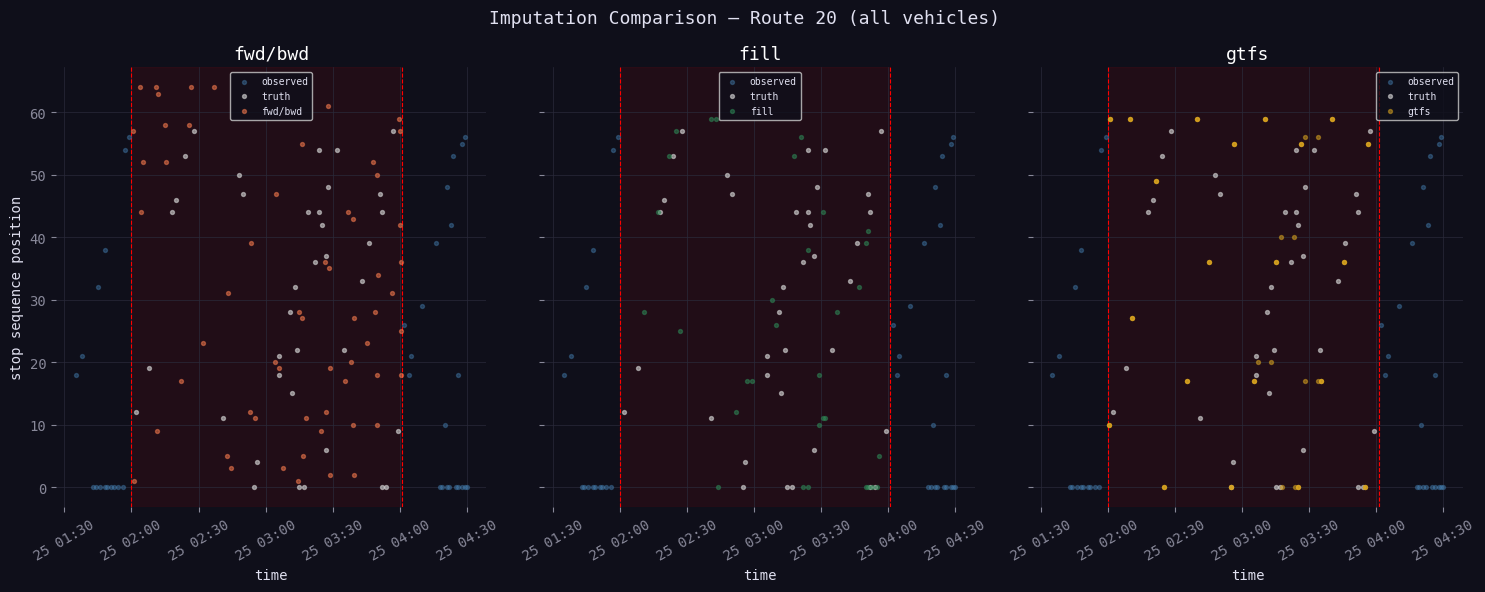


=== Coverage ===
         n_rows  n_routes  n_vehicles
method                               
fwd/bwd    4176       100         528
fill       4896        37         186
gtfs       2419        43         778


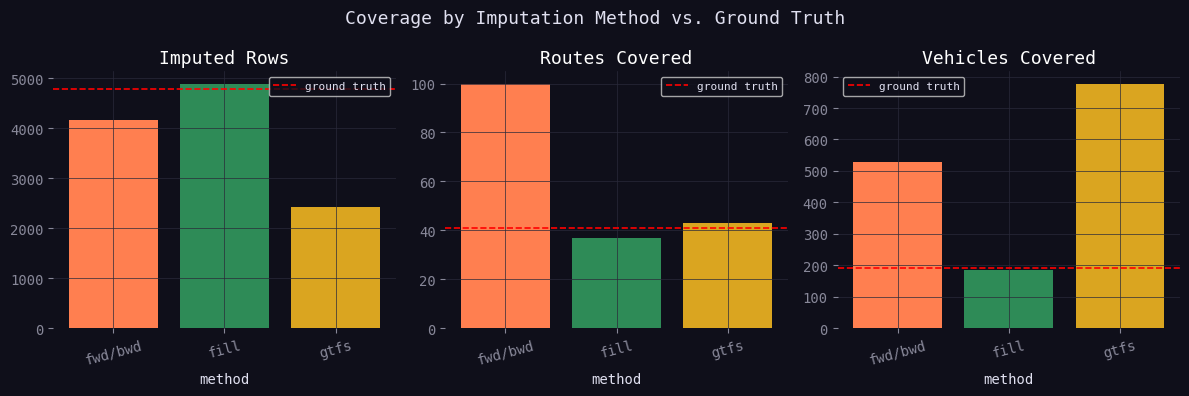

In [191]:
coverage_df = compare_imputation_methods(
    gapped_df      = gapped_df_FAKE,
    truth_df       = truth_df_FAKE,
    gaps_df        = gaps_df_FAKE,
    route_stop_sequences = route_stop_sequences,
    results = {
        "fwd/bwd":     result_df_FAKE_fwdbwd,
        "fill":        result_df_FAKE_fill,
        "gtfs":        result_df_FAKE_gtfs,
    },
    route_id = '20', # or '53', '22', '201', '67', '85' '4'
    context_minutes=30
)

In [146]:
gap_start = row_FAKE["gap_start"]
gap_end   = row_FAKE["gap_end"]

results = {
    "fwd/bwd": result_df_FAKE_fwdbwd,
    "fill":    result_df_FAKE_fill,
    "gtfs":    result_df_FAKE_gtfs,
}

routes_per_method = {
    method: set(
        df.loc[
            (df['tmstmp'] >= gap_start) & (df['tmstmp'] <= gap_end),
            'rt'
        ].dropna().unique()
    )
    for method, df in results.items()
}

# Routes that ALL 3 methods imputed data for within the gap window
imputed_routes_across_methods = set.intersection(*routes_per_method.values())

print(f"Routes imputed by all 3 methods ({len(imputed_routes_across_methods)}):")
print(sorted(imputed_routes_across_methods))

Routes imputed by all 3 methods (42):
['12', '15', '151', '169', '20', '22', '28', '29', '34', '35', '36', '4', '47', '49', '52', '52A', '53', '53A', '54', '55', '6', '60', '62', '63', '63W', '66', '67', '72', '74', '76', '77', '79', '80', '81', '82', '85', '87', '9', '94', '95', 'J14', 'N5']


### IMPUTING OVER THE REAL GAP

In [172]:
bus_with_stops_df = match_bus_to_stops(bus_df, stops_df, trips_df, stop_times_df)
gaps_df = detect_gaps(bus_with_stops_df, min_gap_minutes = 10)

Matched 3062076/8234861 rows (37.2%) to a stop
Found 1 gaps longer than 10 minutes
          gap_start             gap_end  duration_minutes
2026-02-24 04:05:00 2026-02-24 09:38:00             333.0


In [177]:
row = gaps_df.iloc[0]
gap_start = row["gap_start"]
gap_end = row["gap_end"]

In [179]:
gap_start

Timestamp('2026-02-24 04:05:00')

In [182]:
result_df_fill = impute_gap_fill(bus_with_stops_df, gaps_df, gap_start, gap_end)


Imputed 179130 rows from next-week same-period data
Routes covered: 116 / 116 active routes


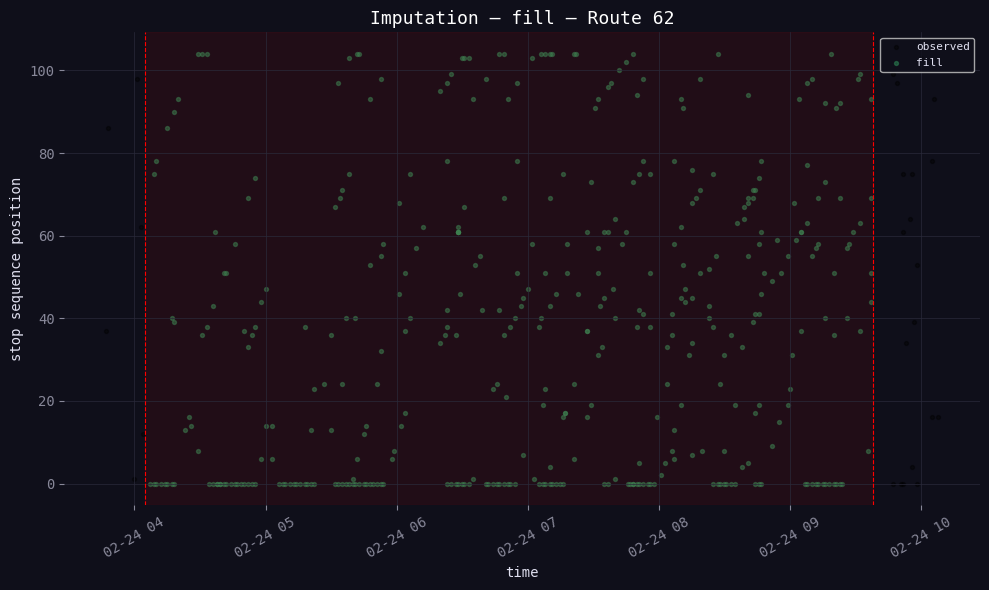

In [193]:
bus_with_stops_df["tmstmp"] = pd.to_datetime(bus_with_stops_df["tmstmp"])
plot_imputation(bus_with_stops_df, gaps_df, route_stop_sequences, "fill", result_df_fill, route_id='62') # 53, 201

In [188]:
result_df_fill.head()

,vid,tmstmp,lat,lon,hdg,pid,rt,des,pdist,dly,...,tablockid,zone,mode,psgld,stst,stsd,pulled_at,rt_chunk,stop_id,source
0,1004,2026-02-23 07:00:00,41.831512,-87.621758,358,8085,1,Union Station,73,False,...,1 -706,NaN,1,NaN,25140,2026-02-23,2026-02-23 07:00:10 CST,"1,2,3,4,X4,N5,6,7,8,8A",NaN,NaN
1,1004,2026-02-23 07:01:00,41.837803,-87.621864,4,8085,1,Union Station,2360,False,...,1 -706,NaN,1,NaN,25140,2026-02-23,2026-02-23 07:01:46 CST,"1,2,3,4,X4,N5,6,7,8,8A",NaN,NaN
2,1004,2026-02-23 07:03:00,41.838378,-87.621892,333,8085,1,Union Station,2569,False,...,1 -706,NaN,1,NaN,25140,2026-02-23,2026-02-23 07:03:22 CST,"1,2,3,4,X4,N5,6,7,8,8A",1563.0,NaN
3,1004,2026-02-23 07:04:00,41.842072,-87.623261,353,8085,1,Union Station,4139,False,...,1 -706,NaN,1,NaN,25140,2026-02-23,2026-02-23 07:04:58 CST,"1,2,3,4,X4,N5,6,7,8,8A",1565.0,NaN
4,1004,2026-02-23 07:06:00,41.846026,-87.623350,354,8085,1,Union Station,5582,False,...,1 -706,NaN,1,NaN,25140,2026-02-23,2026-02-23 07:06:34 CST,"1,2,3,4,X4,N5,6,7,8,8A",1567.0,NaN


In [189]:
# export result_df_fill as csv
result_df_fill.to_csv("all_data_imputed_with_stops.csv", index=False)
